# MotorNet air hockey
Run top to bottom. The smoke test catches bugs in ~1 min before the long run.

In [1]:
%pip install -q motornet gymnasium matplotlib
!nvidia-smi -L || echo 'no NVIDIA GPU, CPU is OK too'

/Users/briandepasquale/Documents/GitHub/MotorNet/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
zsh:1: command not found: nvidia-smi
no NVIDIA GPU, CPU is OK too


In [2]:
# Checkpoints are saved locally next to the notebook
CKPT = 'air_hockey.pt'

In [3]:
%%writefile motornet_air_hockey.py
"""
Two MotorNet arms playing air hockey against each other.

Each player is a MotorNet RigidTendonArm26 (6 lumped Hill muscles, 2-DoF arm) driven by
its own GRU policy. The puck, walls and mallet contacts are simulated with smooth
(softplus) penalty forces, so the whole game -- muscles, skeletons, puck physics -- is
differentiable and both policies are trained end to end with BPTT, each on its own
(opposing) loss. Contact forces are fed back to each arm as an endpoint load, so the
players feel the puck.

Geometry (table frame, metres):
  Player A's shoulder at (0, 0), facing +y.
  Player B's shoulder at (0, 1.2), facing -y (its frame is A's rotated 180 deg).
  Table: x in [-0.25, 0.25], y in [0.15, 1.05]; goals are gaps of width 0.18 in each end wall.
  Each arm reaches ~0.64 m, so each player naturally covers its own half.

Usage:
  pip install motornet gymnasium matplotlib imageio-ffmpeg
  python motornet_air_hockey.py --resume                 # train (CPU, batch 256, 1000 iters)
  python motornet_air_hockey.py --play air_hockey.pt     # render a game to air_hockey.mp4/gif

Status and notes for whoever picks this up
------------------------------------------
- Written against the motornet 0.3.0 (PyTorch) API. Runs end to end in Colab; a full
  training run has not been completed yet, so hyperparameters are untuned.
- motornet quirk: effector.to(device) does not update the muscle's/skeleton's own `device`
  attribute, so Player.__init__ moves them explicitly. Without that, CUDA runs crash in reset().
- Benchmark (Colab, one training iteration, original 250-step episodes and 5 substeps):
      cpu  batch 8 / 64 / 256:  11.5 / 6.8 / 8.7 s
      cuda batch 8 / 64 / 256:  12.3 / 11.2 / 11.5 s
  The rollout is thousands of tiny sequential ops, so it is launch-overhead bound: the GPU
  doesn't help and batch size is nearly free. Defaults are therefore CPU, batch 256, with
  150-step episodes and 2 physics substeps (contacts remain stable at h = 5 ms).
- Checkpoints every 50 iterations (policies, optimizers, iteration); --resume continues.
- What to watch in the log: `chase` should fall first (arms learn to reach the puck),
  then goal rates should start moving.
- Known risks: each player's gradient also flows through the opponent's policy via the
  puck (implicit opponent shaping), and BPTT through repeated collisions can be noisy.
  If training destabilises: detach the opponent's observation inputs, use a softer BETA,
  shorter episodes, or truncated BPTT. Without the chase shaping, both arms tend to learn
  to sit still.
- Possible speedups if needed: torch.compile on puck_step / the policy step, or fusing the
  per-step physics; the per-iteration cost is dominated by Python/kernel overhead.
"""
import argparse
from collections import deque

import numpy as np
import torch
import torch.nn.functional as F
import motornet as mn

# ----------------------------------------------------------------------------------------
# Constants
# ----------------------------------------------------------------------------------------
DT = 0.01            # effector timestep (s)
T_STEPS = 250        # 2.5 s episodes
SUBSTEPS = 5         # puck physics substeps per effector step (contacts are stiff)

HALF_W = 0.25        # table half-width
Y_A, Y_B = 0.15, 1.05  # end walls (A defends Y_A, B defends Y_B)
MID = 0.5 * (Y_A + Y_B)
SHOULDER_B_Y = 1.2
GOAL_HALF = 0.09

R_PUCK, R_MALLET = 0.025, 0.035
M_PUCK = 0.1
K_CONTACT, C_CONTACT = 600.0, 3.0   # mallet-puck spring / damper
K_WALL = 1500.0
PUCK_DRAG = 0.15
BETA = 300.0         # softplus sharpness (1/m) for contacts and walls
BETA_GOAL = 150.0    # sharpness of the soft goal indicator

PROP_DELAY = 2       # 20 ms proprioceptive delay
VIS_DELAY = 5        # 50 ms visual delay
PUCK_NOISE = 0.0     # optional brownian kick on puck velocity (m/s per sqrt(s)); 0.2 is a faint jitter
LOAD_GAIN = 1.0      # scale on puck reaction force fed back to the arm

HAND_CENTER = torch.tensor([0.0, 0.45])


# ----------------------------------------------------------------------------------------
# Frames: player 0 = A (table frame), player 1 = B (rotated 180 deg about (0, 0.6))
# ----------------------------------------------------------------------------------------
def pos_to_table(p, player):
    if player == 0:
        return p
    return torch.stack([-p[:, 0], SHOULDER_B_Y - p[:, 1]], dim=-1)


pos_from_table = pos_to_table  # the transform is its own inverse


def vec_to_table(v, player):  # velocities and forces
    return v if player == 0 else -v


vec_from_table = vec_to_table


# ----------------------------------------------------------------------------------------
# Differentiable puck physics
# ----------------------------------------------------------------------------------------
def soft_pen(x):
    """Smooth penetration depth: ~max(x, 0) with a ~3 mm rounded corner."""
    return F.softplus(BETA * x) / BETA


def contact_force(p, v, pm, vm):
    """Force on puck (p, v) from a mallet (pm, vm). Spring + damper along the normal."""
    d = p - pm
    dist = torch.sqrt((d ** 2).sum(-1, keepdim=True) + 1e-8)
    n = d / dist
    overlap = (R_PUCK + R_MALLET) - dist
    pen = soft_pen(overlap)
    gate = torch.sigmoid(BETA * overlap)
    v_rel_n = ((v - vm) * n).sum(-1, keepdim=True)
    mag = K_CONTACT * pen - C_CONTACT * gate * v_rel_n
    return F.relu(mag) * n  # contacts only push


def wall_force(p):
    x, y = p[:, 0:1], p[:, 1:2]
    fx = K_WALL * (soft_pen(-HALF_W + R_PUCK - x) - soft_pen(x - HALF_W + R_PUCK))
    # end walls exist only outside the goal mouth
    outside_mouth = torch.sigmoid(BETA * (x.abs() - GOAL_HALF))
    fy = K_WALL * outside_mouth * (soft_pen(Y_A + R_PUCK - y) - soft_pen(y - Y_B + R_PUCK))
    return torch.cat([fx, fy], dim=-1)


def puck_step(p, v, pA, vA, pB, vB):
    """Advance the puck one effector step. Mallet states are in the table frame.
    Returns new puck state and the mean force each mallet applied to the puck."""
    h = DT / SUBSTEPS
    fA_acc, fB_acc = 0.0, 0.0
    for s in range(SUBSTEPS):
        # mallets move linearly within the step
        pA_s, pB_s = pA + vA * h * s, pB + vB * h * s
        fA = contact_force(p, v, pA_s, vA)
        fB = contact_force(p, v, pB_s, vB)
        f = fA + fB + wall_force(p) - PUCK_DRAG * v
        v = v + h * f / M_PUCK + PUCK_NOISE * h ** 0.5 * torch.randn_like(v)  # semi-implicit Euler + jitter
        p = p + h * v
        fA_acc, fB_acc = fA_acc + fA, fB_acc + fB
    return p, v, fA_acc / SUBSTEPS, fB_acc / SUBSTEPS


def soft_in_goal(p, which):
    """Soft indicator that the puck is past an end line inside the goal mouth."""
    x, y = p[..., 0], p[..., 1]
    mouth = torch.sigmoid(BETA_GOAL * (GOAL_HALF - x.abs()))
    past = torch.sigmoid(BETA_GOAL * (Y_A - y)) if which == "A" else torch.sigmoid(BETA_GOAL * (y - Y_B))
    return mouth * past


# ----------------------------------------------------------------------------------------
# Players
# ----------------------------------------------------------------------------------------
def make_arm():
    return mn.effector.RigidTendonArm26(muscle=mn.muscle.RigidTendonHillMuscle(), timestep=DT)


class Player:
    def __init__(self, idx, hidden=128, device="cpu"):
        self.idx = idx
        self.arm = make_arm().to(device)
        # motornet's .to() only updates the effector's own `device` attribute; the muscle and
        # skeleton keep reporting CPU (their buffers move, but tensors they create don't).
        self.arm.muscle.to(device)
        self.arm.skeleton.to(device)
        self.n_obs = 12 + 2 + 4 + 2 + 6  # prop, own hand, puck pos/vel, opponent hand, efference copy
        self.policy = mn.policy.PolicyGRU(self.n_obs, hidden, self.arm.n_muscles, device=device)
        self.device = device

    def reset(self, batch):
        # shoulder ~45 deg, elbow ~90 deg, with jitter -> hand near (0, 0.45) in own frame
        q = np.deg2rad(np.array([45.0, 90.0])) + np.deg2rad(8.0) * np.random.randn(batch, 2)
        self.arm.reset(options={"batch_size": batch, "joint_state": torch.tensor(q, dtype=torch.float32)})
        self.h = self.policy.init_hidden(batch)
        self.u = torch.zeros(batch, self.arm.n_muscles, device=self.device)
        self.prop_buf = deque(maxlen=PROP_DELAY + 1)
        self.vis_buf = deque(maxlen=VIS_DELAY + 1)

    # ---- state in the table frame ----
    def hand_table(self):
        c = self.arm.states["cartesian"]
        return pos_to_table(c[:, :2], self.idx), vec_to_table(c[:, 2:], self.idx)

    def proprioception(self):
        m = self.arm.states["muscle"]
        mlen = m[:, 1:2, :] / self.arm.muscle.l0_ce   # same normalisation as mn.environment
        mvel = m[:, 2:3, :] / self.arm.muscle.vmax
        return torch.cat([mlen, mvel], dim=-1).squeeze(1)

    def observe(self, puck_p, puck_v, opp_hand_table):
        """Egocentric, delayed observations. Both players see the game from their own side."""
        c = HAND_CENTER.to(puck_p.device)
        own = (self.arm.states["fingertip"] - c) / 0.3
        pp = (pos_from_table(puck_p, self.idx) - c) / 0.3
        pv = vec_from_table(puck_v, self.idx) / 2.0
        op = (pos_from_table(opp_hand_table, self.idx) - c) / 0.3
        prop, vis = self.proprioception(), torch.cat([own, pp, pv, op], -1)
        if not self.prop_buf:  # fill buffers on first call
            self.prop_buf.extend([prop] * (PROP_DELAY + 1))
            self.vis_buf.extend([vis] * (VIS_DELAY + 1))
        self.prop_buf.append(prop)
        self.vis_buf.append(vis)
        return torch.cat([self.prop_buf[0], self.vis_buf[0], self.u], -1)

    def act(self, obs, noise=0.0):
        u, self.h = self.policy(obs, self.h)
        if noise > 0:
            u = (u + noise * torch.randn_like(u)).clamp(0, 1)
        self.u = u
        return u

    def step(self, u, load_on_hand_table):
        self.arm.step(u, endpoint_load=LOAD_GAIN * vec_from_table(load_on_hand_table, self.idx))


# ----------------------------------------------------------------------------------------
# Rollout
# ----------------------------------------------------------------------------------------
def init_puck(batch, device):
    # anywhere on the table, aimed roughly along the long axis (toward a goal/player) with a
    # wide angular spread, so the puck doesn't just slide sideways into the side walls
    x = (torch.rand(batch, device=device) - 0.5) * 0.4
    y = MID + (torch.rand(batch, device=device) - 0.5) * 0.6
    sign = torch.where(torch.rand(batch, device=device) < 0.5, 1.0, -1.0)
    ang = sign * np.pi / 2 + (torch.rand(batch, device=device) - 0.5) * (np.pi * 0.9)
    spd = 0.2 + 1.3 * torch.rand(batch, device=device)
    return torch.stack([x, y], -1), torch.stack([spd * torch.cos(ang), spd * torch.sin(ang)], -1)


def rollout(A, B, batch, T=T_STEPS, noise=0.0, record=False):
    device = A.device
    A.reset(batch)
    B.reset(batch)
    p, v = init_puck(batch, device)
    hist = {"puck": [], "A": [], "B": [], "qA": [], "qB": [], "uA": [], "uB": []}
    traj_p, uA_all, uB_all, dA_all, dB_all = [], [], [], [], []
    fA = fB = torch.zeros(batch, 2, device=device)

    for t in range(T):
        pA, vA = A.hand_table()
        pB, vB = B.hand_table()
        uA = A.act(A.observe(p, v, pB), noise)
        uB = B.act(B.observe(p, v, pA), noise)
        # reaction force of the puck on each mallet (from the previous step's contacts)
        A.step(uA, -fA)
        B.step(uB, -fB)
        pA, vA = A.hand_table()
        pB, vB = B.hand_table()
        p, v, fA, fB = puck_step(p, v, pA, vA, pB, vB)

        traj_p.append(p)
        uA_all.append(uA)
        uB_all.append(uB)
        dA_all.append((pA - p).norm(dim=-1))
        dB_all.append((pB - p).norm(dim=-1))
        if record:
            hist["puck"].append(p[0].detach().cpu().numpy())
            hist["A"].append(pA[0].detach().cpu().numpy())
            hist["B"].append(pB[0].detach().cpu().numpy())
            hist["qA"].append(A.arm.states["joint"][0, :2].detach().cpu().numpy())
            hist["qB"].append(B.arm.states["joint"][0, :2].detach().cpu().numpy())
            hist["uA"].append(uA[0].detach().cpu().numpy())
            hist["uB"].append(uB[0].detach().cpu().numpy())

    P = torch.stack(traj_p, 1)  # (batch, T, 2)
    return dict(P=P, uA=torch.stack(uA_all, 1), uB=torch.stack(uB_all, 1),
                dA=torch.stack(dA_all, 1), dB=torch.stack(dB_all, 1), hist=hist)


def losses(out, w_terr=0.5, w_chase=1.0, w_effort=1e-2):
    P = out["P"]
    goal_on_A = soft_in_goal(P, "A").amax(1)
    goal_on_B = soft_in_goal(P, "B").amax(1)

    # zero-sum part: goals and territory (puck in the opponent's half)
    terr = ((P[..., 1] - MID) / (Y_B - MID)).mean(1)  # >0 means puck on B's side
    zs_A = (goal_on_B - goal_on_A) + w_terr * terr

    # shaping: go get the puck when it's on your side
    onA = torch.sigmoid((MID - P[..., 1]) / 0.03)
    chase_A = (onA * out["dA"]).mean(1)
    chase_B = ((1 - onA) * out["dB"]).mean(1)

    L_A = (-zs_A + w_chase * chase_A + w_effort * out["uA"].pow(2).mean((1, 2))).mean()
    L_B = (zs_A + w_chase * chase_B + w_effort * out["uB"].pow(2).mean((1, 2))).mean()
    stats = dict(goals_A=(goal_on_B > 0.5).float().mean().item(),
                 goals_B=(goal_on_A > 0.5).float().mean().item(),
                 chase_A=chase_A.mean().item(), chase_B=chase_B.mean().item())
    return L_A, L_B, stats


# ----------------------------------------------------------------------------------------
# Training: simultaneous gradient play, each net descends only its own loss
# ----------------------------------------------------------------------------------------
def train(args):
    torch.manual_seed(args.seed)
    np.random.seed(args.seed)
    A, B = Player(0, args.hidden, args.device), Player(1, args.hidden, args.device)
    optA = torch.optim.Adam(A.policy.parameters(), lr=args.lr)
    optB = torch.optim.Adam(B.policy.parameters(), lr=args.lr)
    pA, pB = list(A.policy.parameters()), list(B.policy.parameters())
    global SUBSTEPS
    SUBSTEPS = args.substeps
    start = 0
    if args.resume:
        import os
        if os.path.exists(args.ckpt):
            ck = torch.load(args.ckpt, map_location=args.device)
            A.policy.load_state_dict(ck["A"]); B.policy.load_state_dict(ck["B"])
            if "optA" in ck:
                optA.load_state_dict(ck["optA"]); optB.load_state_dict(ck["optB"])
            start = ck.get("it", 0)
            print(f"resumed from {args.ckpt} at iteration {start}")
        else:
            print(f"no checkpoint at {args.ckpt}, starting fresh")

    for it in range(start, args.iters):
        # curriculum: lean on the chase shaping early, let the game take over later
        w_chase = max(0.2, 2.0 * (1 - it / (0.6 * args.iters)))
        out = rollout(A, B, args.batch, T=args.episode, noise=args.noise)
        L_A, L_B, st = losses(out, w_chase=w_chase)

        gA = torch.autograd.grad(L_A, pA, retain_graph=True)
        gB = torch.autograd.grad(L_B, pB)
        for prm, g in zip(pA, gA):
            prm.grad = g
        for prm, g in zip(pB, gB):
            prm.grad = g
        torch.nn.utils.clip_grad_norm_(pA, 1.0)
        torch.nn.utils.clip_grad_norm_(pB, 1.0)
        optA.step()
        optB.step()

        if it % 25 == 0:
            print(f"it {it:5d} | L_A {L_A.item():+.3f} L_B {L_B.item():+.3f} | "
                  f"goals A {st['goals_A']:.2f} B {st['goals_B']:.2f} | "
                  f"chase A {st['chase_A']:.3f} B {st['chase_B']:.3f}", flush=True)
        if (it + 1) % 50 == 0 or it == args.iters - 1:
            torch.save({"A": A.policy.state_dict(), "B": B.policy.state_dict(),
                        "optA": optA.state_dict(), "optB": optB.state_dict(),
                        "it": it + 1, "hidden": args.hidden}, args.ckpt)
    return A, B


# ----------------------------------------------------------------------------------------
# Visualisation
# ----------------------------------------------------------------------------------------
def play(args):
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from matplotlib import animation
    try:   # a bundled ffmpeg, if available
        import imageio_ffmpeg
        matplotlib.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()
    except ImportError:
        pass

    global SUBSTEPS
    SUBSTEPS = args.substeps
    ck = torch.load(args.play, map_location=args.device)
    A, B = Player(0, ck["hidden"], args.device), Player(1, ck["hidden"], args.device)
    A.policy.load_state_dict(ck["A"])
    B.policy.load_state_dict(ck["B"])
    with torch.no_grad():
        out = rollout(A, B, 1, T=args.T, record=True)
    H = {k: np.array(v) for k, v in out["hist"].items()}
    L1, L2 = A.arm.skeleton.L1, A.arm.skeleton.L2

    def arm_pts(q, player):
        sh = np.zeros(2)
        el = np.array([L1 * np.cos(q[0]), L1 * np.sin(q[0])])
        hd = el + np.array([L2 * np.cos(q.sum()), L2 * np.sin(q.sum())])
        pts = np.stack([sh, el, hd])
        if player == 1:
            pts = np.stack([-pts[:, 0], SHOULDER_B_Y - pts[:, 1]], -1)
        return pts

    fig, ax = plt.subplots(figsize=(4, 8))
    ax.set_aspect("equal")
    ax.set_xlim(-0.45, 0.45)
    ax.set_ylim(-0.05, 1.25)
    ax.axis("off")
    ax.add_patch(plt.Rectangle((-HALF_W, Y_A), 2 * HALF_W, Y_B - Y_A, fc="#e8f4fa", ec="k"))
    ax.plot([-HALF_W, HALF_W], [MID, MID], "k--", lw=0.8)
    for y in (Y_A, Y_B):
        ax.plot([-GOAL_HALF, GOAL_HALF], [y, y], color="crimson", lw=4)
    armA, = ax.plot([], [], "-o", color="tab:blue", lw=4)
    armB, = ax.plot([], [], "-o", color="tab:orange", lw=4)
    malA = ax.add_patch(plt.Circle((0, 0), R_MALLET, color="tab:blue"))
    malB = ax.add_patch(plt.Circle((0, 0), R_MALLET, color="tab:orange"))
    puck = ax.add_patch(plt.Circle((0, 0), R_PUCK, color="k"))
    txt = ax.text(-0.43, 1.2, "", fontsize=9)

    def frame(t):
        a, b = arm_pts(H["qA"][t], 0), arm_pts(H["qB"][t], 1)
        armA.set_data(a[:, 0], a[:, 1])
        armB.set_data(b[:, 0], b[:, 1])
        malA.center, malB.center, puck.center = H["A"][t], H["B"][t], H["puck"][t]
        txt.set_text(f"t = {t * DT:.2f} s")
        return armA, armB, malA, malB, puck, txt

    anim = animation.FuncAnimation(fig, frame, frames=len(H["puck"]), interval=1000 * DT, blit=True)
    try:
        anim.save("air_hockey.mp4", fps=int(1 / DT), dpi=120)
        print("saved air_hockey.mp4")
    except Exception as e:
        print(f"mp4 failed ({e})")
    anim.save("air_hockey.gif", fps=int(1 / DT) // 2, dpi=80)   # always keep a gif on disk too
    print("saved air_hockey.gif")


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--iters", type=int, default=1000)
    ap.add_argument("--batch", type=int, default=256)
    ap.add_argument("--episode", type=int, default=150, help="training episode length in 10 ms steps")
    ap.add_argument("--substeps", type=int, default=2, help="puck physics substeps per step")
    ap.add_argument("--resume", action="store_true", help="continue from --ckpt if it exists")
    ap.add_argument("--hidden", type=int, default=128)
    ap.add_argument("--lr", type=float, default=1e-3)
    ap.add_argument("--noise", type=float, default=0.01, help="motor noise on muscle commands")
    ap.add_argument("--seed", type=int, default=0)
    ap.add_argument("--device", default="cpu", help="CPU benchmarked faster than GPU here")
    ap.add_argument("--ckpt", default="air_hockey.pt")
    ap.add_argument("--play", default=None, help="checkpoint to render instead of training")
    ap.add_argument("--T", type=int, default=600, help="steps to render in --play mode")
    args = ap.parse_args()
    play(args) if args.play else train(args)


Writing motornet_air_hockey.py


## Smoke test
A few iterations at small batch: checks shapes and gives a per-iteration timing to extrapolate from.

In [4]:
import sys
import time, subprocess
t0 = time.time()
!{sys.executable} motornet_air_hockey.py --iters 6 --batch 8 --ckpt smoke.pt
print(f'~{(time.time()-t0)/6:.1f} s/iter at batch 8 (includes startup)')

it     0 | L_A +0.156 L_B +0.175 | goals A 0.00 B 0.00 | chase A 0.096 B 0.070
~1.3 s/iter at batch 8 (includes startup)


MovieWriter ffmpeg unavailable; using Pillow instead.
MovieWriter ffmpeg unavailable; using Pillow instead.
saved air_hockey.gif


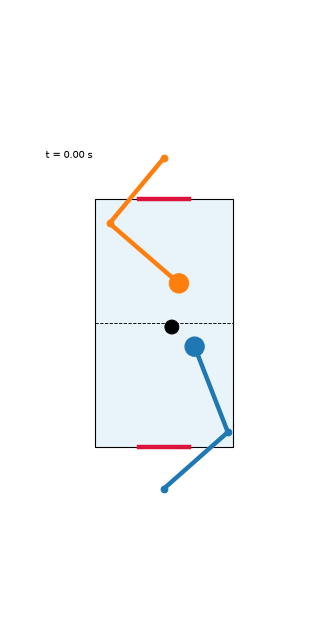

In [5]:
import sys
!{sys.executable} motornet_air_hockey.py --play smoke.pt --T 200
from IPython.display import Video, Image, display
import os
display(Video('air_hockey.mp4', embed=True) if os.path.exists('air_hockey.mp4') else Image('air_hockey.gif'))

## Full training
CPU benchmarked faster than GPU for this workload, so a CPU runtime is fine. Re-running this cell after a disconnect resumes from the last checkpoint. Watch `chase` fall first, then goal rates move.

In [6]:
import sys
!{sys.executable} motornet_air_hockey.py --iters 1000 --batch 256 --ckpt "$CKPT" --resume 2>&1 | tee train_log.txt

no checkpoint at air_hockey.pt, starting fresh
it     0 | L_A +0.200 L_B +0.220 | goals A 0.01 B 0.00 | chase A 0.100 B 0.110
it    25 | L_A +0.186 L_B +0.147 | goals A 0.01 B 0.02 | chase A 0.085 B 0.089
it    50 | L_A +0.148 L_B +0.148 | goals A 0.01 B 0.04 | chase A 0.074 B 0.088
it    75 | L_A +0.192 L_B +0.198 | goals A 0.06 B 0.04 | chase A 0.133 B 0.090
it   100 | L_A +0.142 L_B +0.139 | goals A 0.02 B 0.02 | chase A 0.080 B 0.089
it   125 | L_A +0.116 L_B +0.143 | goals A 0.00 B 0.01 | chase A 0.076 B 0.087
it   150 | L_A +0.159 L_B +0.108 | goals A 0.01 B 0.02 | chase A 0.085 B 0.093
it   175 | L_A +0.171 L_B +0.137 | goals A 0.03 B 0.02 | chase A 0.118 B 0.099
it   200 | L_A +0.108 L_B +0.111 | goals A 0.02 B 0.02 | chase A 0.077 B 0.087
it   225 | L_A +0.163 L_B +0.160 | goals A 0.04 B 0.05 | chase A 0.116 B 0.143
it   250 | L_A +0.082 L_B +0.106 | goals A 0.01 B 0.01 | chase A 0.079 B 0.082
it   275 | L_A +0.087 L_B +0.084 | goals A 0.01 B 0.01 | chase A 0.077 B 0.080
it   

MovieWriter ffmpeg unavailable; using Pillow instead.
MovieWriter ffmpeg unavailable; using Pillow instead.
saved air_hockey.gif


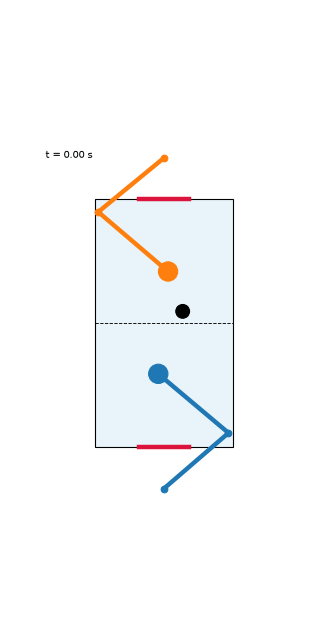

In [7]:
import sys
!{sys.executable} motornet_air_hockey.py --play "$CKPT" --T 600
display(Video('air_hockey.mp4', embed=True) if os.path.exists('air_hockey.mp4') else Image('air_hockey.gif'))